<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_6/enc_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 6: Estatística descritiva e análise de distribuições

**Instrutor:** Jhonatan Lopes

::: {.callout-note}
### Continuidade com o Encontro 5

Este notebook continua a análise iniciada no Encontro 5. As células iniciais
reconstroem apenas o conjunto de dados e sua representação computacional para
permitir que o notebook também seja executado de forma independente.
:::


In [1]:
#| code-fold: true
#| code-summary: "Mostrar importações"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [2]:
#| code-fold: true
#| code-summary: "Mostrar preparação dos dados"

arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/"
    "eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(
    arxiv_url,
    dtype={"paper_id": "string"},
)

In [3]:
arxiv_df.head()

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
0,2001.04171,Multi-Sensor Data and Knowledge Fusion -- A Pr...,Fusion is a common tool for the analysis and u...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,1,3,12,108,False,False
1,2001.04417,Maximal Closed Set and Half-Space Separations ...,Several concept learning problems can be regar...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,3,3,2,10,170,False,False
2,2002.00509,A Machine Consciousness architecture based on ...,Recent developments in machine learning have p...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,2,1,11,197,False,False
3,2003.03875,Overview of the CCKS 2019 Knowledge Graph Eval...,Knowledge graph models world knowledge as conc...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,25,1,2,14,92,False,False
4,2003.06492,On Sufficient and Necessary Conditions in Boun...,Computation Tree Logic (CTL) is one of the cen...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,5,3,2,11,203,False,False


In [4]:
arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          3387 non-null   string
 1   title             3387 non-null   str   
 2   abstract_preview  3387 non-null   str   
 3   primary_category  3387 non-null   str   
 4   category_label    3387 non-null   str   
 5   top_level         3387 non-null   str   
 6   top_level_label   3387 non-null   str   
 7   year              3387 non-null   int64 
 8   decade            3387 non-null   str   
 9   n_authors         3387 non-null   int64 
 10  n_versions        3387 non-null   int64 
 11  n_categories      3387 non-null   int64 
 12  title_n_words     3387 non-null   int64 
 13  abstract_n_words  3387 non-null   int64 
 14  has_doi           3387 non-null   bool  
 15  has_journal_ref   3387 non-null   bool  
dtypes: bool(2), int64(6), str(7), string(1)
memory usage: 377.2 KB


In [5]:
#| code-fold: true
#| code-summary: "Mostrar preparação dos dados"

arxiv_df = arxiv_df.astype(
    {
        "title": "string",
        "abstract_preview": "string",
        "primary_category": "category",
        "category_label": "category",
        "top_level": "category",
        "top_level_label": "category",
        "decade": "category",
        "has_doi": "bool",
        "has_journal_ref": "bool",
    }
)

arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   paper_id          3387 non-null   string  
 1   title             3387 non-null   string  
 2   abstract_preview  3387 non-null   string  
 3   primary_category  3387 non-null   category
 4   category_label    3387 non-null   category
 5   top_level         3387 non-null   category
 6   top_level_label   3387 non-null   category
 7   year              3387 non-null   int64   
 8   decade            3387 non-null   category
 9   n_authors         3387 non-null   int64   
 10  n_versions        3387 non-null   int64   
 11  n_categories      3387 non-null   int64   
 12  title_n_words     3387 non-null   int64   
 13  abstract_n_words  3387 non-null   int64   
 14  has_doi           3387 non-null   bool    
 15  has_journal_ref   3387 non-null   bool    
dtypes: bool(2), category(5), int64(6), 

## 1. Inspeção univariada como procedimento reutilizável

No Encontro 5, examinamos uma variável quantitativa combinando resumos
numéricos e representações gráficas da distribuição.

Esse procedimento será aplicado a outras variáveis. Podemos, portanto,
encapsular a construção do histograma e da ECDF em uma função reutilizável.

A função abaixo recebe um `DataFrame`, o nome da variável e algumas opções de
representação. O histograma mostra a distribuição local das observações; a ECDF
mostra sua acumulação ao longo da escala. Média e mediana são incluídas como
referências de localização no histograma.

In [6]:
def plot_hist_ecdf(
    dataframe: pd.DataFrame,
    column: str,
    variable_label: str,
    bins: int = 30,
    discrete: bool = False,
) -> None:
    values = dataframe[column].dropna()

    mean_value = values.mean()
    median_value = values.median()

    fig, (ax_hist, ax_ecdf) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5),
    )

    sns.histplot(
        x=values,
        bins=bins,
        discrete=discrete,
        stat="count",
        edgecolor="white",
        ax=ax_hist,
    )

    ax_hist.axvline(
        x=mean_value,
        linestyle="--",
        label=f"Média: {mean_value:.2f}",
    )

    ax_hist.axvline(
        x=median_value,
        linestyle="-",
        label=f"Mediana: {median_value:.2f}",
    )

    ax_hist.set_title(
        f"Histograma: {variable_label}",
        fontsize=14,
    )

    ax_hist.set(
        xlabel=variable_label,
        ylabel="Número de observações",
    )

    ax_hist.legend(frameon=False)

    sns.ecdfplot(
        x=values,
        stat="percent",
        ax=ax_ecdf,
    )

    ax_ecdf.set_title(
        f"ECDF: {variable_label}",
        fontsize=14,
    )

    ax_ecdf.set(
        xlabel=variable_label,
        ylabel="Percentual acumulado",
        ylim=(0, 100),
    )

    for axis in (ax_hist, ax_ecdf):
        axis.set_axisbelow(True)
        axis.grid(
            True,
            alpha=0.4,
            linewidth=0.5,
            color="grey",
        )

    sns.despine(
        fig=fig,
        top=True,
        right=True,
        trim=True,
        offset=10,
    )

    plt.tight_layout()
    plt.show()

### Inspeção univariada inicial

Uma primeira descrição de uma variável quantitativa pode combinar três
perspectivas complementares:

1. `.describe()` resume localização, dispersão e quantis;
2. o histograma representa a distribuição das frequências ao longo da escala;
3. a ECDF representa as proporções acumuladas.

As três representações preservam aspectos diferentes da distribuição. Sua
interpretação deve considerar também a escala da variável, os valores que ela
pode assumir e as exigências do procedimento estatístico associado à pergunta
de pesquisa.

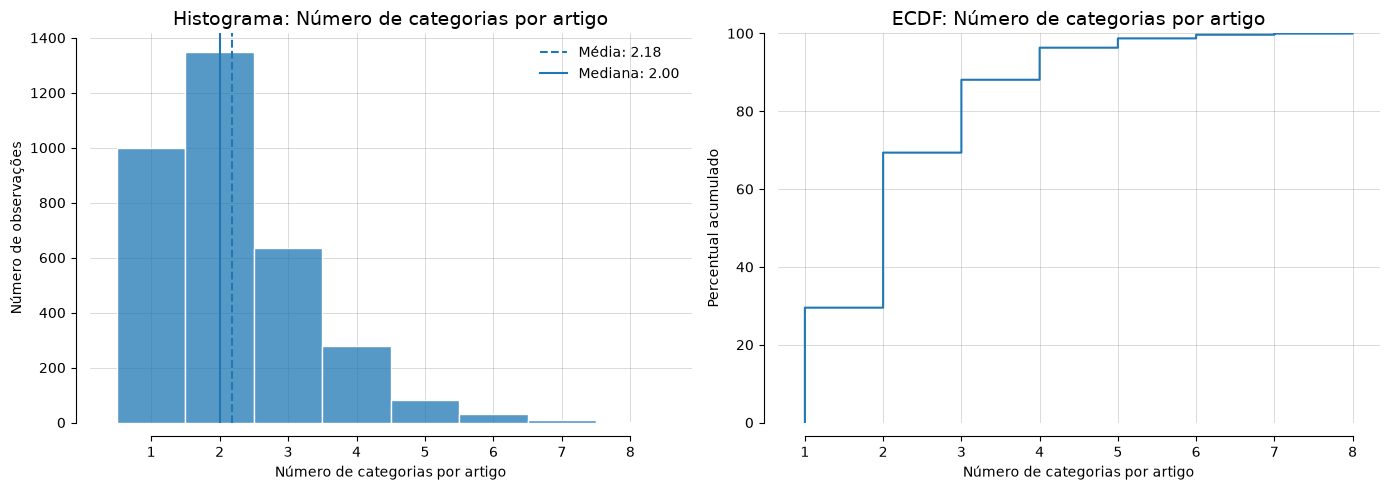

In [7]:
plot_hist_ecdf(
    dataframe=arxiv_df,
    column="n_categories",
    variable_label="Número de categorias por artigo",
    discrete=True,
)

## 2. Comprimento dos abstracts

`abstract_n_words` registra o número de palavras no abstract de cada artigo.
A unidade de observação continua sendo o artigo, e a variável é uma contagem
quantitativa discreta.

Diferentemente de `n_categories`, que assume apenas alguns valores possíveis,
`abstract_n_words` apresenta uma escala muito mais extensa. Para uma variável
discreta com muitos valores possíveis, histogramas com intervalos podem ser
úteis para representar a forma geral da distribuição.

### 2.1 Variabilidade em relação à média

Para dados de contagem, a relação entre média e variância pode fornecer
informação sobre a magnitude da heterogeneidade observada.

A distribuição de Poisson oferece uma referência simples: em uma variável
aleatória de Poisson com parâmetro $\lambda$,

$$
E(Y) = \operatorname{Var}(Y) = \lambda.
$$

A razão

$$
\frac{s^2}{\bar{x}}
$$

permite comparar a variância observada com essa referência. Valores próximos
de `1` são compatíveis, nesse aspecto específico, com a relação média–variância
de uma Poisson; valores muito maiores indicam variabilidade superior à prevista
por uma única taxa Poisson homogênea.

Aqui, essa razão será utilizada como uma descrição da heterogeneidade dos
comprimentos observados. A comparação mais direta com uma distribuição de
Poisson será feita posteriormente.

In [ ]:
arxiv_df["abstract_n_words"].describe()

count    3387.000000
mean      172.085326
std        47.876997
min        38.000000
25%       139.000000
50%       171.000000
75%       204.000000
max       310.000000
Name: abstract_n_words, dtype: float64

Os 3.387 abstracts apresentam média de aproximadamente `172` palavras e
mediana de `171`. O primeiro e o terceiro quartis são `139` e `204`,
respectivamente, e o desvio-padrão é de aproximadamente `48` palavras.

A proximidade entre média e mediana descreve a localização central da
distribuição. A forma completa e a distribuição das observações ao redor desse
centro serão examinadas graficamente.

In [ ]:
abstract_values = arxiv_df["abstract_n_words"].dropna()

abstract_mean = abstract_values.mean()
abstract_var = abstract_values.var(ddof=1)
variance_to_mean = abstract_var / abstract_mean

print(f"Média: {abstract_mean:.2f}")
print(f"Variância: {abstract_var:.2f}")
print(f"Razão variância/média: {variance_to_mean:.2f}")

Média: 172.09
Variância: 2292.21
Razão variância/média: 13.32


A variância observada é aproximadamente `13.3` vezes a média. Em relação à
referência média–variância de uma distribuição de Poisson, os comprimentos dos
abstracts apresentam heterogeneidade elevada.

Esse resultado é plausível para comprimentos textuais: artigos diferentes podem
produzir abstracts com extensões substancialmente diferentes. A razão descreve
essa discrepância em relação à referência de Poisson; sua interpretação não
depende de classificar a variabilidade como erro ou anomalia.

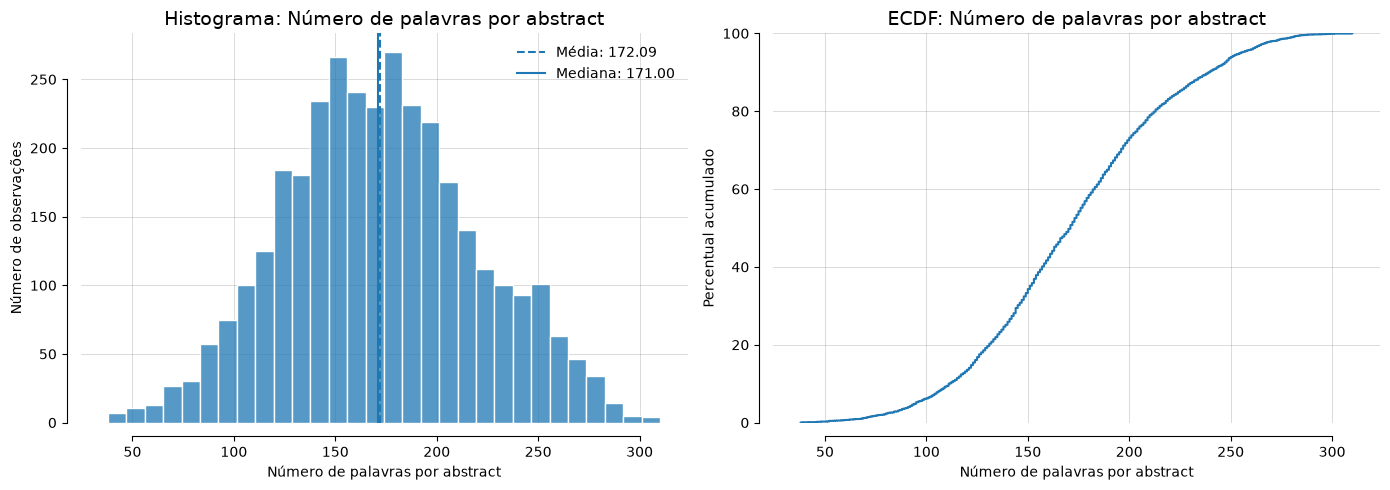

In [ ]:
#| label: fig-abstract-histograma-ecdf
#| fig-cap: "Histograma e ECDF do número de palavras por abstract."
#| fig-alt: "Dois painéis representam os comprimentos observados: o histograma concentra a maior parte dos abstracts perto do centro, e a ECDF mostra a acumulação ao longo da escala."

plot_hist_ecdf(
    dataframe=arxiv_df,
    column="abstract_n_words",
    variable_label="Número de palavras por abstract",
    bins=30,
    discrete=False,
)

O histograma e a ECDF complementam os resumos numéricos. A média e a mediana
localizam o centro; o desvio-padrão e a razão variância/média quantificam
aspectos da variabilidade; as representações gráficas mostram como essa
variabilidade se distribui ao longo da escala observada.

A próxima questão consiste em comparar a forma dessa distribuição com uma
referência teórica.

### 2.2 Comparação com uma distribuição normal: gráfico Q–Q

Um gráfico Q–Q (*quantile–quantile plot*) compara os valores ordenados da
distribuição observada com os quantis esperados de uma distribuição teórica.
Aqui, a referência é a distribuição normal.

Se os quantis observados mantêm uma relação aproximadamente linear com os
quantis teóricos, os pontos se distribuem próximos de uma reta. Desvios
sistemáticos dessa relação mostram onde a distribuição observada difere da
referência.

Em `scipy.stats.probplot()`, a reta exibida é ajustada aos pontos do gráfico.
Sua inclinação e seu intercepto acomodam a localização e a escala dos dados;
o diagnóstico concentra-se, portanto, nos desvios em relação à linearidade.

Curvaturas e afastamentos nas caudas permitem identificar diferenças de
assimetria, concentração ou extensão das caudas em relação à distribuição
normal considerada como referência.

O gráfico Q–Q é um diagnóstico da forma da distribuição. Sua relevância
metodológica depende do procedimento estatístico e do objeto ao qual o
pressuposto correspondente se aplica.

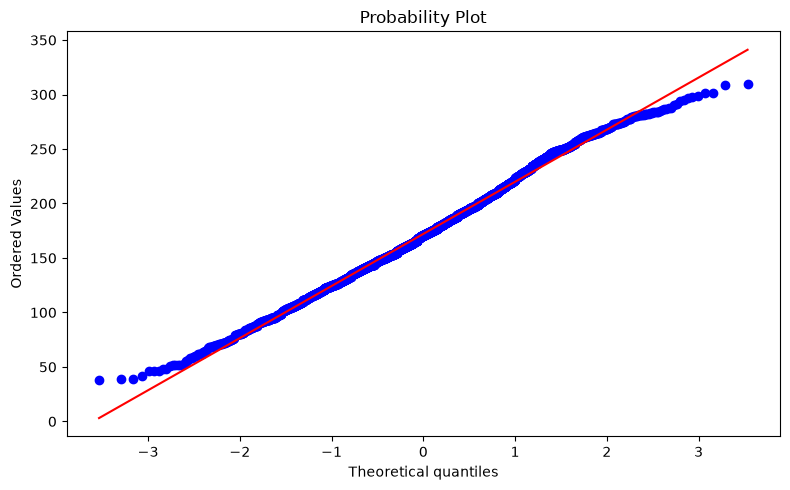

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

stats.probplot(
    abstract_values,
    dist="norm",
    plot=ax,
)

plt.tight_layout()
plt.show()

`stats.probplot()` já produz o diagnóstico completo com a configuração padrão.
A célula seguinte modifica apenas sua apresentação gráfica; os quantis, a
distribuição de referência e a reta ajustada permanecem os mesmos.

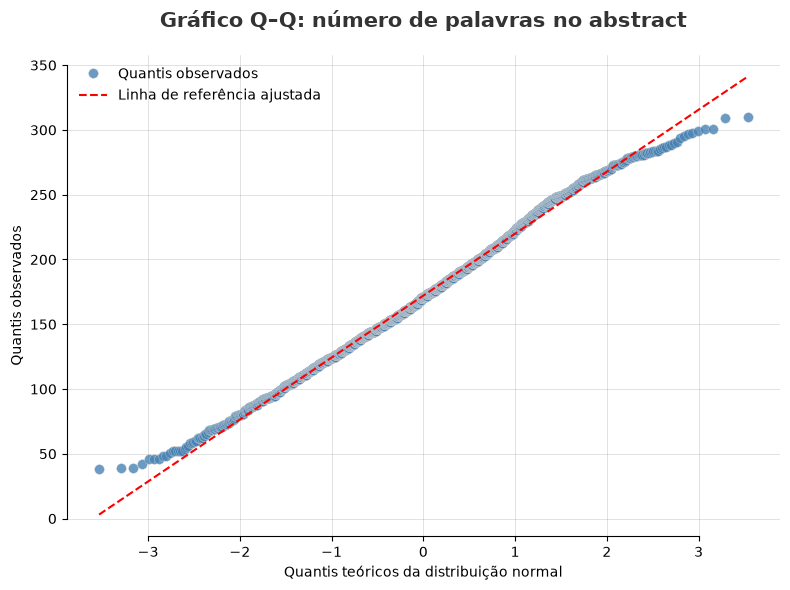

In [ ]:
#| label: fig-abstract-qq
#| fig-cap: "Gráfico Q–Q dos comprimentos de abstract em relação à distribuição normal."
#| fig-alt: "Os quantis centrais ficam próximos da reta ajustada, enquanto os menores valores aparecem acima dela e os maiores aparecem abaixo."

fig, ax = plt.subplots(figsize=(8, 6))

stats.probplot(
    abstract_values,
    dist="norm",
    plot=ax,
)

observed_points, reference_line = ax.lines

observed_points.set(
    markeredgewidth=0.3,
    markersize=7,
    alpha=0.8,
    color="steelblue",
    markeredgecolor="lightgrey",
    label="Quantis observados",
)

reference_line.set(
    linestyle="--",
    linewidth=1.5,
    label="Linha de referência ajustada",
)

ax.set_title(
    "Gráfico Q–Q: número de palavras no abstract",
    fontsize=15,
    fontweight="bold",
    pad=20,
    color="#333333",
)
ax.set(
    xlabel="Quantis teóricos da distribuição normal",
    ylabel="Quantis observados",
)

ax.legend(frameon=False)

ax.set_axisbelow(True)
ax.grid(
    True,
    alpha=0.4,
    linewidth=0.4,
    color="grey",
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    trim=True,
)

plt.tight_layout()
plt.show()

A maior parte dos quantis centrais acompanha de perto a relação linear esperada
sob a referência normal.

Nas extremidades, porém, aparece um padrão sistemático. Os menores valores
observados ficam acima da reta ajustada, enquanto os maiores ficam abaixo dela.
As duas caudas observadas são, portanto, menos extensas do que as previstas
pela referência normal ajustada.

O gráfico mostra uma aproximação relativamente boa na região central e
diferenças mais claras nas caudas. Essa informação acrescenta detalhe à
comparação que o histograma havia fornecido sobre a forma da distribuição.

### 2.3 Comparação com uma referência de Poisson

A distribuição de Poisson fornece outra referência útil para variáveis de
contagem. Para uma variável aleatória

$$
Y \sim \operatorname{Poisson}(\lambda),
$$

a média e a variância são determinadas pelo mesmo parâmetro:

$$
E(Y) = \operatorname{Var}(Y) = \lambda.
$$

Podemos, portanto, gerar uma amostra de Poisson com média igual à média
observada de `abstract_n_words` e comparar sua variabilidade com a dos dados
reais.

Essa referência representa uma contagem produzida por uma única taxa
\(\lambda\). A comparação permite visualizar a magnitude da heterogeneidade já
indicada pela razão variância/média calculada anteriormente.

Aqui, a comparação é descritiva. Em modelagem de dados de contagem,
sobredispersão é avaliada em relação à distribuição condicional especificada
pelo modelo e aos respectivos diagnósticos.

In [ ]:
rng = np.random.default_rng(seed=42)

poisson_values = pd.Series(
    rng.poisson(
        lam=abstract_mean,
        size=len(abstract_values),
    ),
    name="poisson",
)

(
    pd.concat(
    [
        abstract_values.describe().rename("observado"),
        poisson_values.describe(),
    ],
    axis=1,
)
    .style.format(precision=2)
    .set_caption("Observado vs. Poisson")

)

,observado,poisson
count,3387.00,3387.00
mean,172.09,171.70
std,47.88,12.85
min,38.00,127.00
25%,139.00,163.00
50%,171.00,172.00
75%,204.00,180.00
max,310.00,220.00


In [ ]:
poisson_mean = poisson_values.mean()
poisson_variance = poisson_values.var(ddof=1)
poisson_variance_to_mean = poisson_variance / poisson_mean

metricas = {
    "Dados observados": {
        "Média": abstract_mean,
        "Variância": abstract_var,
        "Razão Variância/Média": variance_to_mean,
    },
    "Referência de Poisson": {
        "Média": poisson_mean,
        "Variância": poisson_variance,
        "Razão Variância/Média": poisson_variance_to_mean,
    },
}


metricas_df = pd.DataFrame(data=metricas)
metricas_df.style.format(precision=2).set_caption("Observado vs. Referência de Poisson")

,Dados observados,Referência de Poisson
Média,172.09,171.70
Variância,2292.21,165.05
Razão Variância/Média,13.32,0.96


A amostra de Poisson apresenta média próxima à dos dados observados, conforme
definido na simulação. Sua variância também permanece próxima da média, como
esperado para essa distribuição.

Em `abstract_n_words`, a média é aproximadamente `172`, enquanto a variância é
superior a `2.290`. A razão variância/média é, portanto, cerca de `13.3`, muito
acima da relação observada na referência de Poisson.

O contraste mostra que uma única taxa de Poisson representa muito menos
variabilidade do que a observada entre os comprimentos dos abstracts. A
heterogeneidade entre artigos constitui, assim, uma característica importante
da distribuição analisada.

A descrição de `abstract_n_words` reuniu quatro perspectivas complementares:
centro, dispersão, forma da distribuição e comparação com distribuições de
referência.

## 3. Distribuições categóricas

Variáveis categóricas são descritas pela frequência ou pela proporção de
observações pertencentes a cada categoria.

Neste conjunto, `primary_category` registra a categoria principal atribuída a
cada artigo no arXiv. `top_level` representa uma classificação mais ampla dessas
mesmas categorias.

A unidade de observação continua sendo o artigo.

### 3.1 Categorias primárias do arXiv

Começamos pela distribuição dos artigos entre as categorias primárias
observadas no conjunto.

In [ ]:
primary_category_counts = (
    arxiv_df["primary_category"]
    .value_counts()
)

primary_category_proportions = (
    arxiv_df["primary_category"]
    .value_counts(normalize=True)
)

pd.DataFrame(
    {
        "n_articles": primary_category_counts,
        "proportion": primary_category_proportions,
    }
)

,n_articles,proportion
primary_category,,
stat.ML,1000,0.295247
cs.LG,799,0.235902
stat.AP,649,0.191615
cs.CL,493,0.145557
cs.AI,172,0.050782
cs.HC,114,0.033658
cs.CY,77,0.022734
cs.IR,71,0.020963
cs.DL,12,0.003543


As frequências apresentam uma distribuição desigual entre as nove categorias
primárias. `stat.ML`, `cs.LG`, `stat.AP` e `cs.CL` concentram grande parte dos
artigos, enquanto algumas categorias aparecem com frequência muito menor.

A tabela descreve cada categoria separadamente. Podemos também resumir o grau
de concentração da distribuição categórica como um todo.

### 3.2 Entropia de Shannon normalizada

A entropia de Shannon resume como as observações se distribuem entre os níveis
de uma variável categórica.

Para proporções \(p_1, p_2, \ldots, p_K\), a entropia é:

$$
H
=
-\sum_{i=1}^{K}
p_i \ln(p_i)
$$

em que \(K\) corresponde ao número de categorias observadas com frequência
positiva.

Para um número fixo de categorias, a entropia atinge seu valor máximo quando
todas apresentam a mesma proporção:

$$
H_{\max}
=
\ln(K)
$$

Podemos então expressar a entropia relativamente a esse máximo:

$$
H_{\text{norm}}
=
\frac{H}{H_{\max}}
$$

Valores próximos de `1` correspondem a distribuições mais equilibradas entre
as categorias observadas. Valores menores correspondem a maior concentração
das observações em algumas categorias.

Quando apenas uma categoria é observada, adotaremos
\(H_{\text{norm}} = 0\).

A escala normalizada descreve o equilíbrio **dentro da classificação
considerada**. A definição e a granularidade das categorias permanecem parte
da interpretação: uma divisão em duas categorias amplas representa uma
partição diferente de uma divisão em nove categorias mais específicas.

In [ ]:
def normalised_shannon_entropy(series: pd.Series) -> float:
    proportions = series.value_counts(
        normalize=True,
        dropna=False,
    )

    proportions = proportions[proportions > 0]
    n_levels = len(proportions)

    if n_levels <= 1:
        return 0.0

    entropy = -(proportions * np.log(proportions)).sum()
    max_entropy = np.log(n_levels)

    return float(entropy / max_entropy)

In [ ]:
norm_entropy_categories = normalised_shannon_entropy(
    arxiv_df["primary_category"]
)

print(
    "Entropia normalizada de primary_category: "
    f"{norm_entropy_categories:.4f}"
)

Entropia normalizada de primary_category: 0.7967


Para `primary_category`, a entropia normalizada é aproximadamente `0.797`.
Esse valor resume a distribuição desigual observada na tabela de frequências:
algumas categorias concentram uma parcela consideravelmente maior dos artigos
do que outras.

Podemos aplicar o mesmo cálculo a outras classificações categóricas do conjunto.

`category_label` contém os rótulos correspondentes a `primary_category`, e
`top_level_label` contém os rótulos correspondentes a `top_level`. Essas
colunas representam as mesmas partições com nomes diferentes e, por isso,
forneceriam exatamente as mesmas entropias.

Selecionaremos apenas classificações substantivamente distintas.

In [ ]:
categorical_columns = [
    "decade",
    "primary_category",
    "top_level",
]

categorical_summary = pd.DataFrame(
    {
        "n_levels": (
            arxiv_df[categorical_columns]
            .nunique(dropna=False)
        ),
        "normalised_entropy": (
            arxiv_df[categorical_columns]
            .apply(normalised_shannon_entropy)
        ),
    }
).sort_values(
    by="normalised_entropy",
)

categorical_summary

,n_levels,normalised_entropy
decade,1,0.000000
primary_category,9,0.796710
top_level,2,0.999502


A classificação `decade` contém apenas um nível observado neste conjunto, pois
todos os artigos pertencem à mesma década. Sua entropia normalizada é,
portanto, `0`.

`top_level` divide os artigos entre duas categorias amplas com frequências muito
semelhantes, produzindo uma entropia normalizada próxima de `1`.

`primary_category` utiliza nove categorias mais específicas e apresenta maior
concentração em alguns níveis, resultando em uma entropia normalizada de
aproximadamente `0.797`.

Esses valores descrevem o equilíbrio das observações dentro de cada partição
categórica. A granularidade da classificação participa diretamente do
resultado: agrupar categorias específicas em classes mais amplas modifica a
distribuição que está sendo resumida.

## Síntese do encontro

Neste encontro, ampliamos a análise de distribuições para diferentes tipos de
variáveis e diferentes formas de representação.

Para variáveis quantitativas, combinamos medidas de centro e dispersão,
histogramas, ECDFs e comparações com distribuições de referência. Para variáveis
categóricas, examinamos frequências, proporções e entropia de Shannon
normalizada.

Em todos esses casos, a estatística calculada descreve uma propriedade
específica da distribuição. Sua interpretação depende da variável, da unidade
de observação, da forma como os dados foram organizados e da pergunta
estatística formulada.